In [1]:
import numpy as np
import torch
from torch.distributions import constraints
import scipy.stats
from math import sqrt

In [2]:
from sbi.utils import process_prior
from sbi.utils.user_input_checks import process_simulator
from sbi.inference import NPE_C, simulate_for_sbi
import pickle, yaml, os, time, argparse
from pathlib import Path
import matplotlib.pyplot as plt
from examples.lgssm import SVMPrior

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [3]:
trajectories_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/lgssm/data/"
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/lgssm/npe_c/"

experiment_ID = 0
posteriors_config_path = results_path + f"sequential_posterior{experiment_ID}.yaml"
posteriors_path = results_path + f"sequential_posterior{experiment_ID}_posteriors_dict.pkl"

with open(posteriors_config_path, "r") as f:
    posteriors_config = yaml.safe_load(f)

with open(posteriors_path, "rb") as f:
    posteriors_dict = pickle.load(f)

posteriors_config

{'T': 30,
 'density_estimator': 'maf',
 'num_sequential_rounds': 4,
 'num_simulations_per_round': 5000,
 'rho_lower': 0.0,
 'rho_upper': 1.0,
 'simulation_times': [1.9542285000000001,
  0.5314827089999987,
  0.5721308749999992,
  0.4563945419999982],
 'tau_loc': 1.0,
 'tau_lower': 0,
 'tau_scale': 1.0,
 'tau_upper': 2.0,
 'training_times': [16.542760541,
  29.872868542,
  78.80047962500001,
  46.71446225],
 'use_combined_loss': False,
 'x_observed_ID': 0}

In [4]:
# Assign variables
x_observed_ID = posteriors_config["x_observed_ID"]
num_sequential_rounds = posteriors_config["num_sequential_rounds"]
num_simulations_per_round = posteriors_config["num_simulations_per_round"]
simulation_times = posteriors_config["simulation_times"]
training_times = posteriors_config["training_times"]
use_combined_loss = posteriors_config["use_combined_loss"]
density_estimator = posteriors_config["density_estimator"]
tau_loc = posteriors_config["tau_loc"]
tau_scale = posteriors_config["tau_scale"]
tau_lower = posteriors_config["tau_lower"]
tau_upper = posteriors_config["tau_upper"]
rho_lower = posteriors_config["rho_lower"]
rho_upper = posteriors_config["rho_upper"]
T = posteriors_config["T"]


In [5]:
trajectory_path = trajectories_path + f"trajectory{x_observed_ID}.npz"
trajectory_config_path = trajectories_path + f"trajectory{x_observed_ID}.yaml"

trajectory = np.load(trajectory_path)
with open(trajectory_config_path, "r") as f:
    trajectory_config = yaml.safe_load(f)

In [6]:
z = trajectory["z"][: T+1]
x_observed = trajectory["x"][: T+1]

rho_true = trajectory_config["rho_true"]
sigma_true = trajectory_config["sigma_true"]
tau_true = trajectory_config["tau_true"]

In [7]:
round_ID = 1
posterior = posteriors_dict[f"round_{round_ID}"]
samples = posterior.sample((10000,))

rho_samples = samples[:, 0]
tau_samples = samples[:, 1]

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

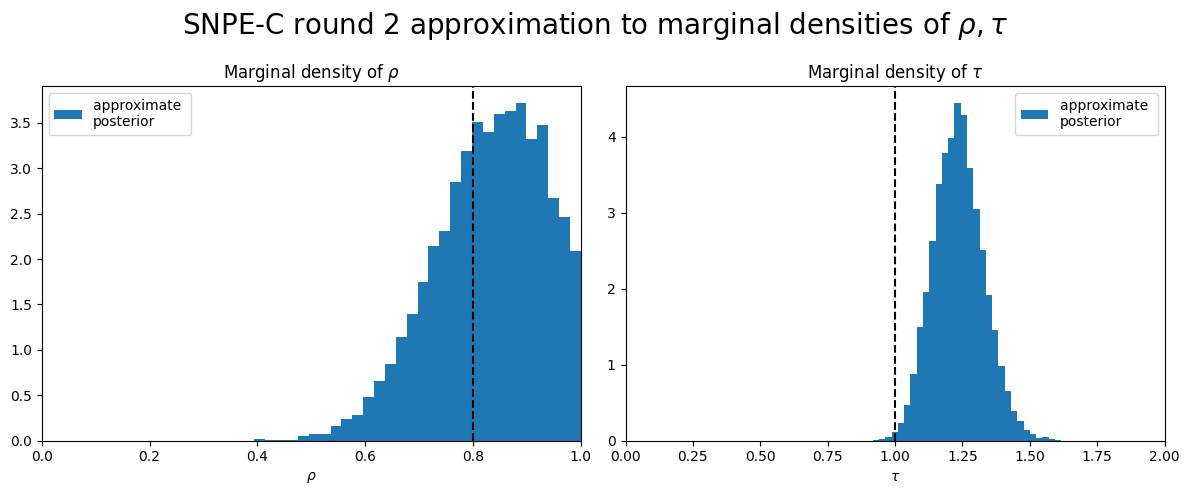

In [8]:
fig, ax = plt.subplots(figsize=(12,5), ncols=2)
bins=30

ax[0].set_xlim(rho_lower, rho_upper)
ax[0].hist(rho_samples, bins=bins, density=True, label="approximate \nposterior")
ax[0].axvline(rho_true, color="k", linestyle="--")
ax[0].set_xlabel(r"$\rho$")
ax[0].set_title(r"Marginal density of $\rho$")
ax[0].legend()

ax[1].set_xlim(tau_lower, tau_upper)
ax[1].hist(tau_samples, bins=bins, density=True, label="approximate \nposterior")
ax[1].axvline(tau_true, color="k", linestyle="--")
ax[1].set_xlabel(r"$\tau$")
ax[1].set_title(r"Marginal density of $\tau$")
ax[1].legend()

plt.suptitle(f"SNPE-C round {round_ID+1} approximation to marginal densities of " + r"$\rho, \tau$", fontsize=20)
plt.tight_layout()
plt.show()

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

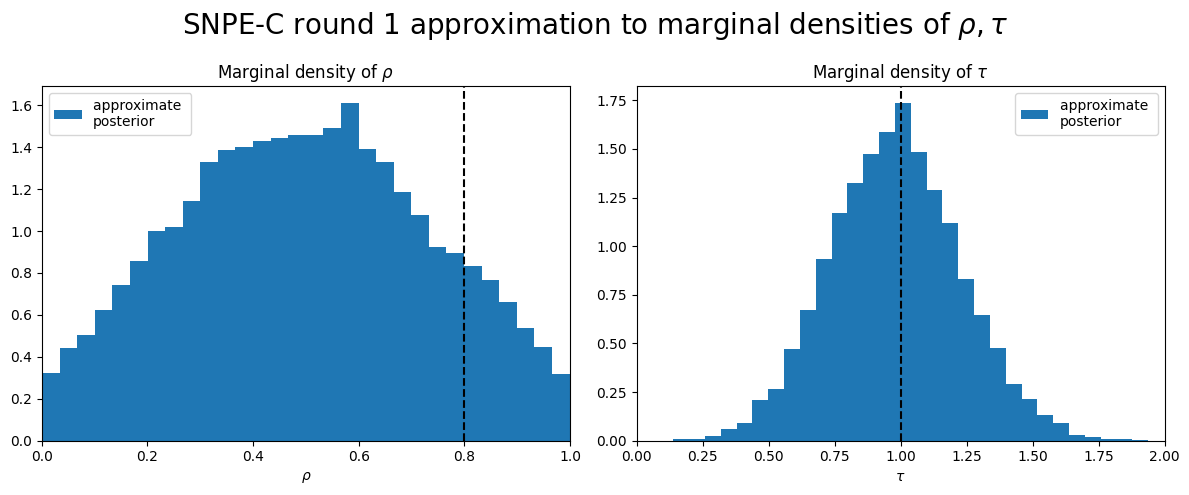

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

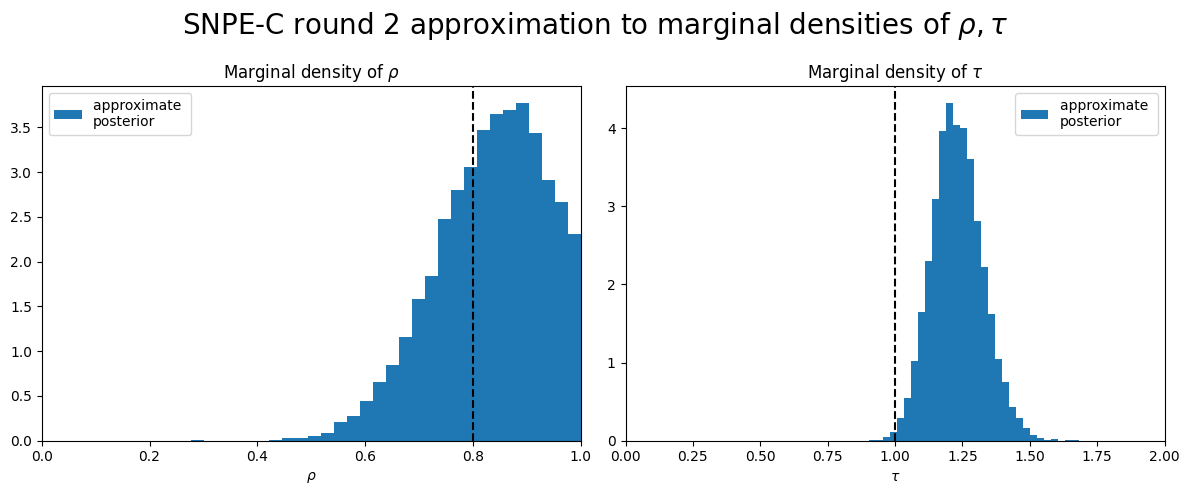

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

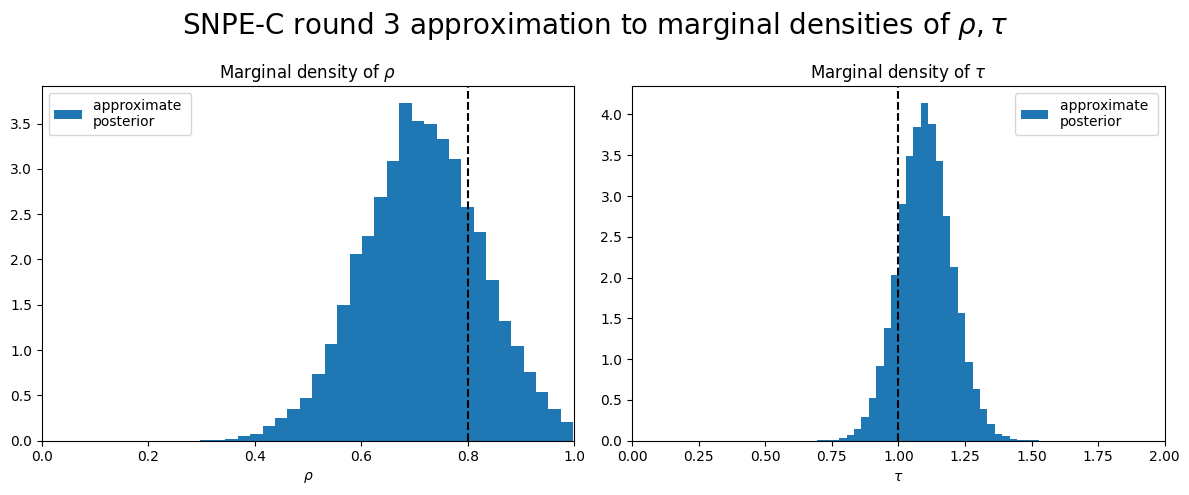

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

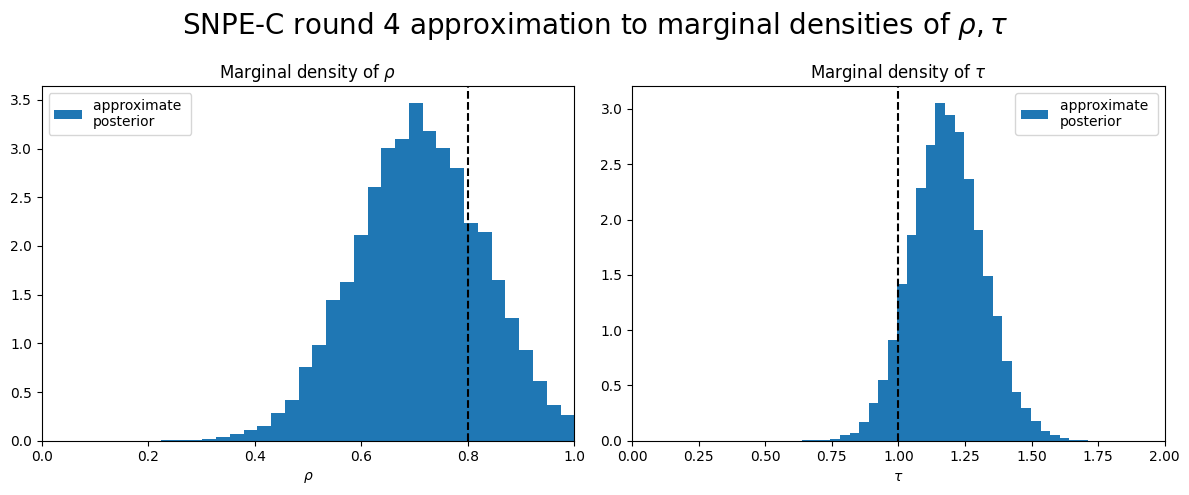

In [9]:
for round_ID in range(num_sequential_rounds):
    posterior = posteriors_dict[f"round_{round_ID}"]
    samples = posterior.sample((10000,))

    rho_samples = samples[:, 0]
    tau_samples = samples[:, 1]

    fig, ax = plt.subplots(figsize=(12,5), ncols=2)
    bins=30

    ax[0].set_xlim(rho_lower, rho_upper)
    ax[0].hist(rho_samples, bins=bins, density=True, label="approximate \nposterior")
    ax[0].axvline(rho_true, color="k", linestyle="--")
    ax[0].set_xlabel(r"$\rho$")
    ax[0].set_title(r"Marginal density of $\rho$")
    ax[0].legend()

    ax[1].set_xlim(tau_lower, tau_upper)
    ax[1].hist(tau_samples, bins=bins, density=True, label="approximate \nposterior")
    ax[1].axvline(tau_true, color="k", linestyle="--")
    ax[1].set_xlabel(r"$\tau$")
    ax[1].set_title(r"Marginal density of $\tau$")
    ax[1].legend()

    plt.suptitle(f"SNPE-C round {round_ID + 1} approximation to marginal densities of " + r"$\rho, \tau$", fontsize=20)
    plt.tight_layout()
    plt.show()

In [11]:
round_ID = 9
posterior = posteriors_dict[f"round_{round_ID}"]
samples = posterior.sample((100000,))

z_0_to_T_samples = samples[:, 2:]

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

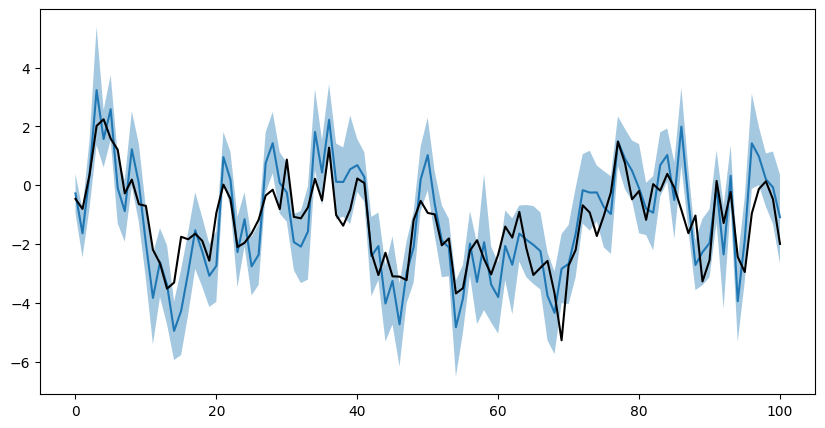

In [13]:
z_0_to_T_samples = np.array(z_0_to_T_samples)
lq = np.quantile(z_0_to_T_samples, 0.025, axis=0)
uq = np.quantile(z_0_to_T_samples, 0.975, axis=0)
mean = np.mean(z_0_to_T_samples, axis=0)
fig, ax = plt.subplots(figsize=(10,5))
time_range = range(T+1)
ax.fill_between(time_range, lq, uq, alpha=0.4)
ax.plot(mean)
ax.plot(z, color="k")